In [103]:
!pip install ucimlrepo
import pandas as pd

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

pd.set_option('display.width', 1000)

magic_data = fetch_ucirepo(id=159) 
X = magic_data.data.features 
y = magic_data.data.targets

# D1 Original Data

In [31]:
X_original = pd.DataFrame(X, columns=X.columns)
display(X_original.agg(['min', 'max']))
display(X_original.head(5))

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
min,4.2835,0.000,1.9413,0.0131,0.0003,-457.9161,-331.780,-205.8947,0.0,1.2826
max,334.1770,256.382,5.3233,0.8930,0.6752,575.2407,238.321,179.8510,90.0,495.5610


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620


In [28]:
y_encoded = y['class'].map({'g': 1, 'h': 0})

# D2 Normalized Data

In [40]:
min_max_scaler = MinMaxScaler()
X_min_max = pd.DataFrame(min_max_scaler.fit_transform(X), columns=X.columns)
X_min_max['class_encoded'] = y_encoded.values
print(X_min_max.agg(['min', 'max']))

print("\n Normalized Data:")
display(X_min_max.head(5))

     fLength  fWidth  fSize  fConc  fConc1  fAsym  fM3Long  fM3Trans  fAlpha  fDist  class_encoded
min      0.0     0.0    0.0    0.0     0.0    0.0      0.0       0.0     0.0    0.0              0
max      1.0     1.0    1.0    1.0     1.0    1.0      1.0       1.0     1.0    1.0              1

 Normalized Data:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class_encoded
0,0.074306,0.062415,0.208043,0.430390,0.293229,0.470032,0.620576,0.512493,0.445467,0.163066,1
1,0.082815,0.045727,0.170668,0.587794,0.558601,0.468649,0.623756,0.507944,0.070677,0.412679,1
2,0.478241,0.530579,0.626818,0.027617,0.027263,0.556215,0.468201,0.416540,0.855111,0.516926,1
3,0.059212,0.037338,0.117445,0.683714,0.580679,0.469558,0.570630,0.515219,0.116100,0.233582,1
4,0.214774,0.120603,0.360674,0.345153,0.271003,0.437870,0.632050,0.590373,0.051644,0.718582,1


In [34]:
X_min_max.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class_encoded
count,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000
mean,0.148432,0.086515,0.261300,0.417351,0.317613,0.439028,0.600465,0.534405,0.307175,0.389528,0.648370
std,0.128420,0.071558,0.139739,0.207766,0.163744,0.057306,0.089458,0.053993,0.290040,0.151194,0.477492
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.060785,0.046274,0.158427,0.253097,0.189917,0.423294,0.559440,0.505632,0.061644,0.285688,0.000000
50%,0.099621,0.066853,0.236044,0.387601,0.290710,0.447105,0.608829,0.535485,0.196439,0.385550,1.000000
75%,0.199576,0.096495,0.343081,0.557563,0.422174,0.466512,0.644829,0.562135,0.509817,0.484102,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# D3 Standardized Data

In [35]:
standard_scaler = StandardScaler()
X_standardized = pd.DataFrame(standard_scaler.fit_transform(X), columns=X.columns)
X_standardized['class_encoded'] = y_encoded.values

print(X_standardized.agg(['mean', 'std']).round(4))

print("\n Standardized Data:")
display(X_standardized.head(5))

      fLength  fWidth  fSize  fConc  fConc1  fAsym  fM3Long  fM3Trans  fAlpha  fDist  class_encoded
mean      0.0    -0.0   -0.0    0.0     0.0   -0.0      0.0      -0.0     0.0   -0.0         0.6484
std       1.0     1.0    1.0    1.0     1.0    1.0      1.0       1.0     1.0    1.0         0.4775

 Standardized Data:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class_encoded
0,-0.577226,-0.336804,-0.381130,0.062759,-0.148923,0.541042,0.224818,-0.405842,0.476816,-1.497866,1
1,-0.510969,-0.570027,-0.648595,0.820383,1.471776,0.516919,0.260364,-0.490094,-0.815418,0.153125,1
2,2.568278,6.205858,2.615783,-1.875883,-1.773241,2.044992,-1.478536,-2.183030,1.889224,0.842635,1
3,-0.694768,-0.687259,-1.029478,1.282069,1.606608,0.532771,-0.333515,-0.355359,-0.658804,-1.031463,1
4,0.516622,0.476384,0.711157,-0.347506,-0.284660,-0.020200,0.353086,1.036620,-0.881039,2.176427,1


In [36]:
X_standardized.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class_encoded
count,1.902000e+04,1.902000e+04,1.902000e+04,1.902000e+04,1.902000e+04,1.902000e+04,19020.000000,1.902000e+04,1.902000e+04,1.902000e+04,19020.000000
mean,7.172671e-17,-1.314990e-16,-2.211574e-16,1.494306e-18,1.102051e-16,-1.195445e-17,0.000000,-8.405474e-18,4.781781e-17,-1.195445e-17,0.648370
std,1.000026e+00,1.000026e+00,1.000026e+00,1.000026e+00,1.000026e+00,1.000026e+00,1.000026,1.000026e+00,1.000026e+00,1.000026e+00,0.477492
min,-1.155862e+00,-1.209064e+00,-1.869959e+00,-2.008809e+00,-1.939745e+00,-7.661315e+00,-6.712427,-9.897993e+00,-1.059103e+00,-2.576420e+00,0.000000
25%,-6.825213e-01,-5.623790e-01,-7.361978e-01,-7.905934e-01,-7.798731e-01,-2.745535e-01,-0.458606,-5.329216e-01,-8.465631e-01,-6.868179e-01,0.000000
50%,-3.800999e-01,-2.747838e-01,-1.807437e-01,-1.431941e-01,-1.643062e-01,1.409487e-01,0.093503,1.999694e-02,-3.818041e-01,-2.631582e-02,1.000000
75%,3.982656e-01,1.394619e-01,5.852541e-01,6.748758e-01,6.385776e-01,4.796163e-01,0.495938,5.136004e-01,6.986894e-01,6.255307e-01,1.000000
max,6.631304e+00,1.276608e+01,5.286407e+00,2.804429e+00,4.167511e+00,9.789330e+00,4.466292,8.623528e+00,2.388785e+00,4.037785e+00,1.000000


# kNN
k = √19020 | random_state is pseudo-random shuffling seed

In [97]:
knn_test_size = 0.2
knn_random_state = 42
n_neighbors = 137

## D1

Accuracy of kNN with original data: 0.7928496319663512
Precision of kNN with original data: 0.7702003878474467
Recall of kNN with original data: 0.96869918699187


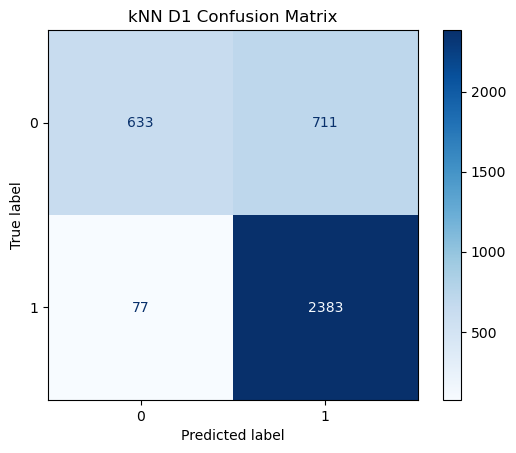

In [98]:
X_train_d1, X_test_d1, y_train, y_test = train_test_split(X_original, y_encoded, test_size=knn_test_size, random_state=knn_random_state)
knn1 = KNeighborsClassifier(n_neighbors=n_neighbors)
knn1.fit(X_train_d1, y_train)

y_knn_predict1 = knn1.predict(X_test_d1)
print("Accuracy of kNN with original data:", accuracy_score(y_test, y_knn_predict1))
print("Precision of kNN with original data:", precision_score(y_test, y_knn_predict1))
print("Recall of kNN with original data:", recall_score(y_test, y_knn_predict1))

knn_cm1 = confusion_matrix(y_test, y_knn_predict1)
knn_disp1 = ConfusionMatrixDisplay(confusion_matrix=knn_cm1, display_labels=knn1.classes_)
knn_disp1.plot(cmap=plt.cm.Blues)

plt.title("kNN D1 Confusion Matrix")
plt.show()

## D2

Accuracy of kNN with min-max scaled data: 1.0
Precision of kNN with min-max scaled data: 1.0
Recall of kNN with min-max scaled data: 1.0


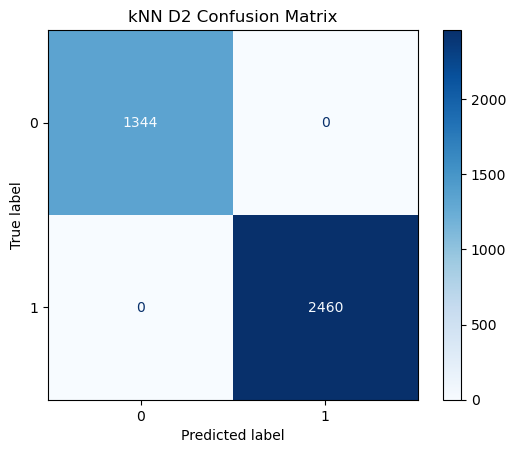

In [99]:
X_train_d2, X_test_d2, y_train, y_test = train_test_split(X_min_max, y_encoded, test_size=knn_test_size, random_state=knn_random_state)
knn2 = KNeighborsClassifier(n_neighbors=n_neighbors)
knn2.fit(X_train_d2, y_train)

y_knn_predict2 = knn2.predict(X_test_d2)
print("Accuracy of kNN with min-max scaled data:", accuracy_score(y_test, y_knn_predict2))
print("Precision of kNN with min-max scaled data:", precision_score(y_test, y_knn_predict2))
print("Recall of kNN with min-max scaled data:", recall_score(y_test, y_knn_predict2))

knn_cm2 = confusion_matrix(y_test, y_knn_predict2)
knn_disp2 = ConfusionMatrixDisplay(confusion_matrix=knn_cm2, display_labels=knn2.classes_)
knn_disp2.plot(cmap=plt.cm.Blues)

plt.title("kNN D2 Confusion Matrix")
plt.show()

## D3

Accuracy of kNN with standardized data: 0.9658254468980021
Precision of kNN with standardized data: 0.9540140296180826
Recall of kNN with standardized data: 0.9951219512195122


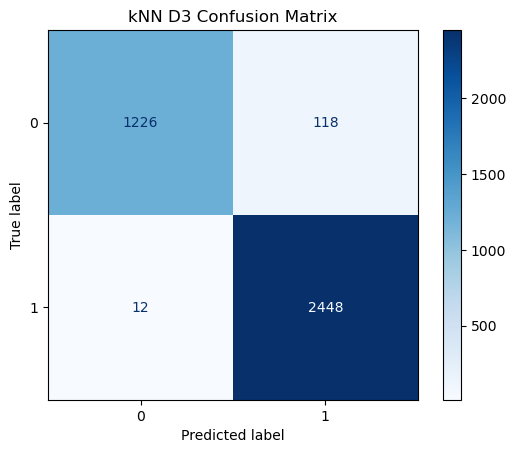

In [100]:
X_train_d3, X_test_d3, y_train, y_test = train_test_split(X_standardized, y_encoded, test_size=knn_test_size, random_state=knn_random_state)
knn3 = KNeighborsClassifier(n_neighbors=n_neighbors)
knn3.fit(X_train_d3, y_train)

y_knn_predict3 = knn3.predict(X_test_d3)
print("Accuracy of kNN with standardized data:", accuracy_score(y_test, y_knn_predict3))
print("Precision of kNN with standardized data:", precision_score(y_test, y_knn_predict3))
print("Recall of kNN with standardized data:", recall_score(y_test, y_knn_predict3))

knn_cm3 = confusion_matrix(y_test, y_knn_predict3)
knn_disp3 = ConfusionMatrixDisplay(confusion_matrix=knn_cm3, display_labels=knn3.classes_)
knn_disp3.plot(cmap=plt.cm.Blues)

plt.title("kNN D3 Confusion Matrix")
plt.show()

# Naïve Bayes
random_state is pseudo-random shuffling seed | Gaussian

In [92]:
nb_test_size = 0.2
nb_random_state = 42

## D1

Accuracy of Naïve Bayes with original data: 0.7268664563617245
Precision of Naïve Bayes with original data: 0.72971225347559
Recall of Naïve Bayes with original data: 0.917479674796748

 Classification Report for Naïve Bayes with original data:
              precision    recall  f1-score   support

           h       0.71      0.38      0.49      1344
           g       0.73      0.92      0.81      2460

    accuracy                           0.73      3804
   macro avg       0.72      0.65      0.65      3804
weighted avg       0.72      0.73      0.70      3804



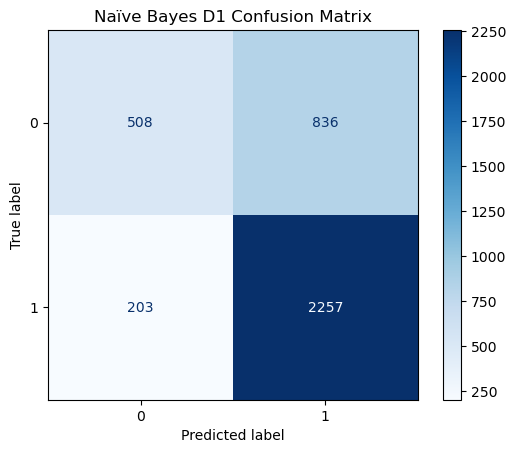

In [94]:
X_train_d1, X_test_d1, y_train, y_test = train_test_split(X_original, y_encoded, test_size=nb_test_size, random_state=nb_random_state)
nb1 = GaussianNB()
nb1.fit(X_train_d1, y_train)

y_nb_predict1 = nb1.predict(X_test_d1)
print("Accuracy of Naïve Bayes with original data:", accuracy_score(y_test, y_nb_predict1))
print("Precision of Naïve Bayes with original data:", precision_score(y_test, y_nb_predict1))
print("Recall of Naïve Bayes with original data:", recall_score(y_test, y_nb_predict1))

print("\n Classification Report for Naïve Bayes with original data:")
print(classification_report(y_test, y_nb_predict1, target_names=['h', 'g']))

nb_cm1 = confusion_matrix(y_test, y_nb_predict1)
nb_disp1 = ConfusionMatrixDisplay(confusion_matrix=nb_cm1, display_labels=nb1.classes_)
nb_disp1.plot(cmap=plt.cm.Blues)

plt.title("Naïve Bayes D1 Confusion Matrix")
plt.show()

## D2

Accuracy of Naïve Bayes with min-max scaled data: 1.0
Precision of Naïve Bayes with min-max scaled data: 1.0
Recall of Naïve Bayes with min-max scaled data: 1.0

 Classification Report for Naïve Bayes with min-max scaled data:
              precision    recall  f1-score   support

           h       1.00      1.00      1.00      1344
           g       1.00      1.00      1.00      2460

    accuracy                           1.00      3804
   macro avg       1.00      1.00      1.00      3804
weighted avg       1.00      1.00      1.00      3804



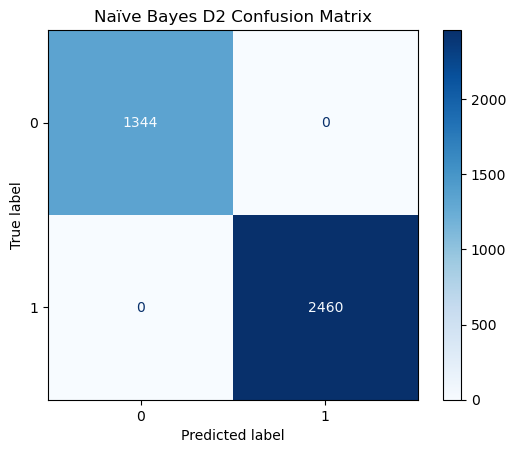

In [95]:
X_train_d2, X_test_d2, y_train, y_test = train_test_split(X_min_max, y_encoded, test_size=nb_test_size, random_state=nb_random_state)
nb2 = GaussianNB()
nb2.fit(X_train_d2, y_train)

y_nb_predict2 = nb2.predict(X_test_d2)
print("Accuracy of Naïve Bayes with min-max scaled data:", accuracy_score(y_test, y_nb_predict2))
print("Precision of Naïve Bayes with min-max scaled data:", precision_score(y_test, y_nb_predict2))
print("Recall of Naïve Bayes with min-max scaled data:", recall_score(y_test, y_nb_predict2))

print("\n Classification Report for Naïve Bayes with min-max scaled data:")
print(classification_report(y_test, y_nb_predict2, target_names=['h', 'g']))

nb_cm2 = confusion_matrix(y_test, y_nb_predict2)
nb_disp2 = ConfusionMatrixDisplay(confusion_matrix=nb_cm2, display_labels=nb2.classes_)
nb_disp2.plot(cmap=plt.cm.Blues)

plt.title("Naïve Bayes D2 Confusion Matrix")
plt.show()

## D3

Accuracy of Naïve Bayes with standardized data: 1.0
Precision of Naïve Bayes with standardized data: 1.0
Recall of Naïve Bayes with standardized data: 1.0

 Classification Report for Naïve Bayes with standardized data:
              precision    recall  f1-score   support

           h       1.00      1.00      1.00      1344
           g       1.00      1.00      1.00      2460

    accuracy                           1.00      3804
   macro avg       1.00      1.00      1.00      3804
weighted avg       1.00      1.00      1.00      3804



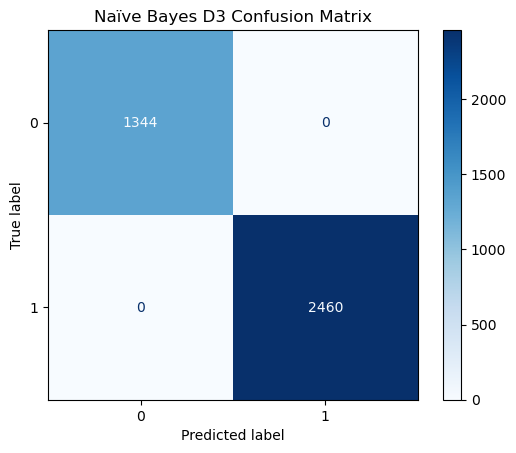

In [96]:
X_train_d3, X_test_d3, y_train, y_test = train_test_split(X_standardized, y_encoded, test_size=nb_test_size, random_state=nb_random_state)
nb3 = GaussianNB()
nb3.fit(X_train_d3, y_train)

y_nb_predict3 = nb3.predict(X_test_d3)
print("Accuracy of Naïve Bayes with standardized data:", accuracy_score(y_test, y_nb_predict3))
print("Precision of Naïve Bayes with standardized data:", precision_score(y_test, y_nb_predict3))
print("Recall of Naïve Bayes with standardized data:", recall_score(y_test, y_nb_predict3))

print("\n Classification Report for Naïve Bayes with standardized data:")
print(classification_report(y_test, y_nb_predict3, target_names=['h', 'g']))

nb_cm3 = confusion_matrix(y_test, y_nb_predict3)
nb_disp3 = ConfusionMatrixDisplay(confusion_matrix=nb_cm3, display_labels=nb3.classes_)
nb_disp3.plot(cmap=plt.cm.Blues)

plt.title("Naïve Bayes D3 Confusion Matrix")
plt.show()

# K-Means Clustering
max_iteration = √(19020/2) | Euclidean Distance THIS CODE NOT YET WORKING NOT YET FINAL. STILL GOING TO CHOOSE WHICH ONE TO USE

In [105]:
max_iteration = 98

In [108]:
kmeans = KMeans(n_clusters=2, init="k-means++", max_iter=max_iteration, random_state=0)
y_means = kmeans.fit_predict(X_min_max)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap="viridis")

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    s=200,
    alpha=0.75,
    marker="X",
    label="Centroids",
)

plt.title("K-Means Clustering (Euclidean Distance)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

InvalidIndexError: (slice(None, None, None), 0)